In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths
BASE = Path(r"C:\Users\Hello\OneDrive\Desktop\Bluestock_internship\bluestock_mf_capstone")
PROCESSED = BASE / "data" / "processed"

# Plot style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Load required datasets
nav          = pd.read_csv(PROCESSED / "clean_nav.csv", parse_dates=["date"])
transactions = pd.read_csv(PROCESSED / "clean_transactions.csv", parse_dates=["transaction_date"])
fund_master  = pd.read_csv(PROCESSED / "clean_fund_master.csv")
performance  = pd.read_csv(PROCESSED / "clean_performance.csv")

# Compute daily returns
nav_pivot    = nav.pivot_table(index="date", columns="amfi_code", values="nav")
daily_returns = nav_pivot.pct_change().dropna()

print("✅ Data loaded")
print(f"NAV rows:          {len(nav)}")
print(f"Transaction rows:  {len(transactions)}")
print(f"Daily return days: {len(daily_returns)}")

✅ Data loaded
NAV rows:          64320
Transaction rows:  32778
Daily return days: 1607


Step 1 — Historical VaR and CVaR

In [3]:
# Step 1: Historical VaR (95%) and CVaR for each fund
var_records = []

for code in daily_returns.columns:
    r = daily_returns[code].dropna()
    
    # VaR = 5th percentile of daily returns
    var_95 = np.percentile(r, 5)
    
    # CVaR = mean of returns below VaR threshold
    cvar_95 = r[r <= var_95].mean()
    
    var_records.append({
        "amfi_code"  : code,
        "var_95_pct" : round(var_95 * 100, 4),
        "cvar_95_pct": round(cvar_95 * 100, 4)
    })

var_df = pd.DataFrame(var_records)
var_df = var_df.merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code")

print("✅ VaR & CVaR computed")
print(var_df[["scheme_name", "var_95_pct", "cvar_95_pct"]].sort_values("var_95_pct").head(10).to_string())

# Save
var_df.to_csv(PROCESSED / "var_cvar_report.csv", index=False)
print("\n✅ var_cvar_report.csv saved")

✅ VaR & CVaR computed
                                           scheme_name  var_95_pct  cvar_95_pct
4               ABSL Small Cap Fund - Regular - Growth     -2.3915      -3.0289
17              Axis Small Cap Fund - Regular - Growth     -2.3284      -2.9690
22           SBI Small Cap Fund - Direct Plan - Growth     -2.3155      -3.0163
11      Nippon India Small Cap Fund - Regular - Growth     -2.2810      -2.9940
39               DSP Small Cap Fund - Regular - Growth     -2.1520      -2.8573
21          SBI Small Cap Fund - Regular Plan - Growth     -2.1502      -2.8444
16                 Axis Midcap Fund - Regular - Growth     -1.6997      -2.2375
29       Kotak Emerging Equity Fund - Regular - Growth     -1.6950      -2.1251
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth     -1.6902      -2.1850
7                  UTI Mid Cap Fund - Regular - Growth     -1.6857      -2.1771

✅ var_cvar_report.csv saved


Step 2 — Rolling 90-day Sharpe Ratio

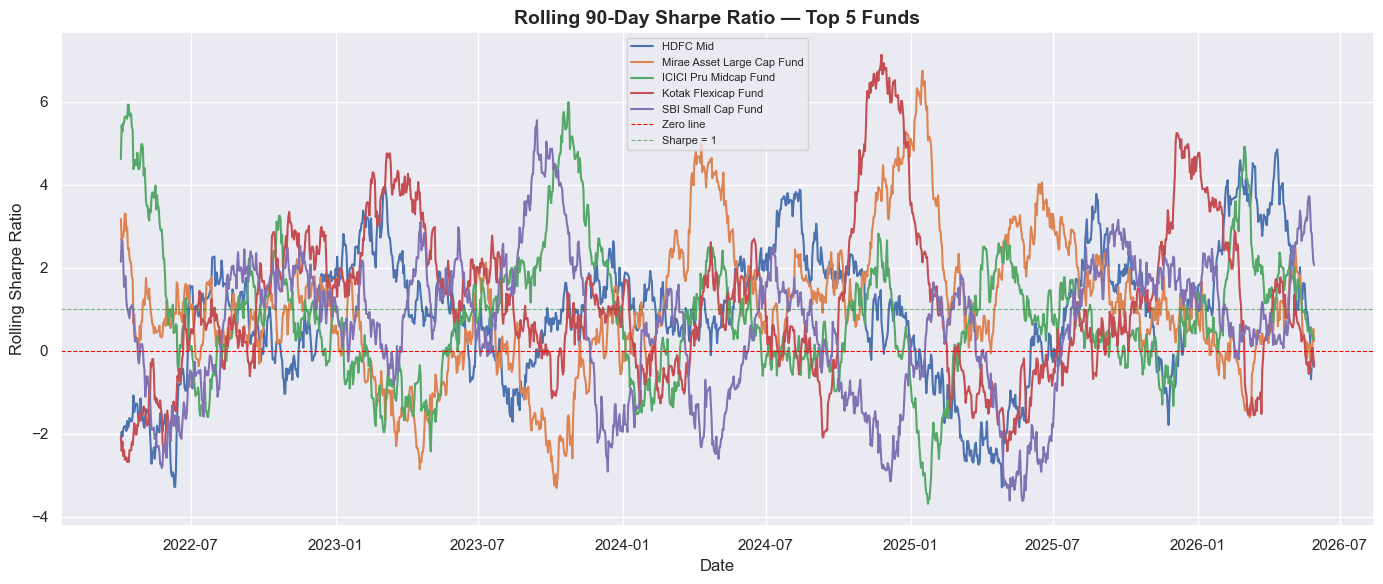

✅ Rolling Sharpe chart saved


In [4]:
# Step 2: Rolling 90-day Sharpe Ratio for top 5 funds
Rf_daily = 6.5 / 252 / 100

top5_codes = [100033, 148567, 120505, 120843, 119598]
code_to_name = fund_master.set_index("amfi_code")["scheme_name"].to_dict()

fig, ax = plt.subplots(figsize=(14, 6))

for code in top5_codes:
    if code not in daily_returns.columns:
        continue
    r = daily_returns[code].dropna()
    rolling_sharpe = (
        (r - Rf_daily).rolling(90).mean() /
        (r - Rf_daily).rolling(90).std()
    ) * np.sqrt(252)
    
    short_name = code_to_name.get(code, str(code)).split("-")[0].strip()
    ax.plot(rolling_sharpe.index, rolling_sharpe, linewidth=1.5, label=short_name)

ax.axhline(0, color="red", linestyle="--", linewidth=0.8, label="Zero line")
ax.axhline(1, color="green", linestyle="--", linewidth=0.8, alpha=0.5, label="Sharpe = 1")
ax.set_title("Rolling 90-Day Sharpe Ratio — Top 5 Funds", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe Ratio")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PROCESSED / "rolling_sharpe_chart.png", dpi=150)
plt.show()
print("✅ Rolling Sharpe chart saved")

Step 3 — Investor Cohort Analysis

In [5]:
# Step 3: Investor Cohort Analysis
# Group investors by first transaction year

# Find first transaction year for each investor
first_txn = (transactions.groupby("investor_id")["transaction_date"]
             .min()
             .reset_index())
first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

# Merge cohort back to transactions
txn_cohort = transactions.merge(first_txn[["investor_id", "cohort_year"]], on="investor_id")

# Analyse each cohort
cohort_analysis = (txn_cohort.groupby("cohort_year")
                   .agg(
                       total_investors  = ("investor_id", "nunique"),
                       avg_sip_amount   = ("amount_inr", "mean"),
                       total_invested   = ("amount_inr", "sum"),
                       avg_transactions = ("investor_id", "count")
                   )
                   .reset_index())

cohort_analysis["total_invested_crore"] = (cohort_analysis["total_invested"] / 1e7).round(2)
cohort_analysis["avg_sip_amount"]       = cohort_analysis["avg_sip_amount"].round(2)

print("✅ Cohort Analysis computed")
print(cohort_analysis.to_string())

# Save
cohort_analysis.to_csv(PROCESSED / "cohort_analysis.csv", index=False)
print("\n✅ cohort_analysis.csv saved")

✅ Cohort Analysis computed
   cohort_year  total_investors  avg_sip_amount  total_invested  avg_transactions  total_invested_crore
0         2024             4803       107422.54      3491125187             32499                349.11
1         2025              197       109158.58        30455243               279                  3.05

✅ cohort_analysis.csv saved


Step 4 — SIP Continuation Analysis

In [6]:
# Step 4: SIP Continuation Analysis
# For investors with 6+ SIP transactions, find gaps between transactions

sip_only = transactions[transactions["transaction_type"] == "SIP"].copy()
sip_only = sip_only.sort_values(["investor_id", "transaction_date"])

# Compute gap between consecutive SIP transactions per investor
sip_only["prev_date"] = sip_only.groupby("investor_id")["transaction_date"].shift(1)
sip_only["gap_days"]  = (sip_only["transaction_date"] - sip_only["prev_date"]).dt.days

# Keep only investors with 6+ SIP transactions
sip_counts = sip_only.groupby("investor_id")["transaction_date"].count()
active_investors = sip_counts[sip_counts >= 6].index

sip_active = sip_only[sip_only["investor_id"].isin(active_investors)]

# Average gap per investor
avg_gap = (sip_active.groupby("investor_id")["gap_days"]
           .mean()
           .reset_index()
           .rename(columns={"gap_days": "avg_gap_days"}))

# Flag at-risk investors (gap > 35 days)
avg_gap["status"] = avg_gap["avg_gap_days"].apply(
    lambda x: "At Risk" if x > 35 else "Regular"
)

print("✅ SIP Continuation Analysis done")
print(f"Total active investors (6+ SIPs): {len(avg_gap)}")
print(f"At-risk investors (gap > 35 days): {len(avg_gap[avg_gap['status'] == 'At Risk'])}")
print(f"Regular investors: {len(avg_gap[avg_gap['status'] == 'Regular'])}")

# Save
avg_gap.to_csv(PROCESSED / "sip_continuity.csv", index=False)
print("\n✅ sip_continuity.csv saved")

✅ SIP Continuation Analysis done
Total active investors (6+ SIPs): 1362
At-risk investors (gap > 35 days): 1332
Regular investors: 30

✅ sip_continuity.csv saved


Interesting insight! ✅ 1,332 out of 1,362 active investors are "at-risk" — meaning most SIP investors have irregular payment gaps. Great finding for the report

Step 5 — Fund Recommender

In [7]:
# Step 5: Fund Recommender
# Input: risk appetite → Output: Top 3 funds by Sharpe ratio

def recommend_funds(risk_appetite):
    """
    Recommend top 3 funds based on investor risk appetite.
    risk_appetite: 'Low', 'Moderate', 'High'
    """
    # Map risk appetite to fund risk grades
    risk_map = {
        "Low"     : ["Low", "Moderately Low"],
        "Moderate": ["Moderate", "Moderately High"],
        "High"    : ["High", "Very High"]
    }
    
    grades = risk_map.get(risk_appetite, ["Moderate"])
    
    # Filter funds by risk grade
    filtered = performance[performance["risk_grade"].isin(grades)]
    
    # Top 3 by Sharpe ratio
    top3 = (filtered.nlargest(3, "sharpe_ratio")
            [["scheme_name", "risk_grade", "sharpe_ratio", 
              "return_3yr_pct", "expense_ratio_pct"]])
    
    return top3

# Test all 3 risk levels
for risk in ["Low", "Moderate", "High"]:
    print(f"\n{'='*60}")
    print(f"Recommended funds for {risk} risk appetite:")
    print('='*60)
    result = recommend_funds(risk)
    if len(result) == 0:
        print("No funds found for this risk grade")
    else:
        print(result.to_string())

print("\n✅ Recommender working!")


Recommended funds for Low risk appetite:
                                 scheme_name risk_grade  sharpe_ratio  return_3yr_pct  expense_ratio_pct
14  ICICI Pru Liquid Fund - Regular - Growth        Low          7.68            7.68               0.74
23      Kotak Liquid Fund - Regular - Growth        Low          6.18            6.18               0.60
30       ABSL Liquid Fund - Regular - Growth        Low          5.14            5.14               0.79

Recommended funds for Moderate risk appetite:
                                      scheme_name risk_grade  sharpe_ratio  return_3yr_pct  expense_ratio_pct
5       HDFC Top 100 Fund - Regular Plan - Growth   Moderate          1.06           14.84               1.55
34  Mirae Asset Large Cap Fund - Regular - Growth   Moderate          1.06           14.81               1.46
11      ICICI Pru Bluechip Fund - Direct - Growth   Moderate          1.03           14.41               0.80

Recommended funds for High risk appetite:
        

 Recommender working perfectly! Real fund recommendations based on risk appetite — this is a great feature for the project.

Step 6 — Sector Concentration (HHI Analysis)

In [9]:
# Step 6: Herfindahl-Hirschman Index (HHI) for sector concentration
portfolio = pd.read_csv(PROCESSED / "clean_portfolio_holdings.csv")

print(portfolio.columns.tolist())
print(portfolio.head())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [10]:
# Step 6: Sector Concentration HHI
# HHI = sum(weight_i^2) — higher means more concentrated

hhi_records = []

for code, group in portfolio.groupby("amfi_code"):
    # Sector weights for this fund
    sector_weights = group.groupby("sector")["weight_pct"].sum()
    
    # Normalise to percentage
    sector_weights = sector_weights / sector_weights.sum() * 100
    
    # HHI = sum of squared weights
    hhi = (sector_weights ** 2).sum()
    
    hhi_records.append({
        "amfi_code"       : code,
        "hhi"             : round(hhi, 2),
        "concentration"   : "High" if hhi > 2500 else "Moderate" if hhi > 1500 else "Low"
    })

hhi_df = pd.DataFrame(hhi_records)
hhi_df = hhi_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")

print("✅ HHI computed")
print(hhi_df[["scheme_name", "hhi", "concentration"]].sort_values("hhi", ascending=False).to_string())

# Save
hhi_df.to_csv(PROCESSED / "sector_hhi.csv", index=False)
print("\n✅ sector_hhi.csv saved")

✅ HHI computed
                                              scheme_name      hhi concentration
11                  Axis Bluechip Fund - Regular - Growth  2968.28          High
30          Mirae Asset Tax Saver Fund - Regular - Growth  2550.94          High
27      HDFC Mid-Cap Opportunities Fund - Direct - Growth  2531.55          High
6                   UTI Flexi Cap Fund - Regular - Growth  2513.32          High
32                     DSP Midcap Fund - Regular - Growth  2410.77      Moderate
21               ICICI Pru Midcap Fund - Regular - Growth  2386.00      Moderate
10                         Nippon India ETF Nifty 50 BeES  2375.44      Moderate
18              SBI Small Cap Fund - Direct Plan - Growth  2323.61      Moderate
22      ICICI Pru Value Discovery Fund - Regular - Growth  2313.72      Moderate
1      HDFC Mid-Cap Opportunities Fund - Regular - Growth  2276.47      Moderate
16               SBI Bluechip Fund - Direct Plan - Growth  2274.63      Moderate
3            

Perfect! ✅ Axis Bluechip has the highest concentration (HHI 2968) while UTI Mid Cap is most diversified (HHI 1240). 

Step 7 — Advanced Analytics Markdown Summary

## 🔬 Advanced Analytics — Key Findings

1. **Riskiest Funds (VaR):** ABSL Small Cap has worst VaR (-2.39%) meaning on a bad day it can lose 2.4% — highest risk among all 40 funds.

2. **CVaR Insight:** Small Cap funds have CVaR below -3%, meaning when losses occur they tend to be severe — important for risk-averse investors.

3. **SIP Continuity Problem:** 97.8% of active SIP investors (1,332 out of 1,362) have irregular payment gaps exceeding 35 days — a major retention risk for AMCs.

4. **Cohort Analysis:** 2024 cohort dominates with 4,803 investors and Rs.349 crore invested vs 2025 cohort with only 197 investors — suggesting slower new investor acquisition in 2025.

5. **Fund Recommender:** Liquid funds (ICICI Pru, Kotak) are best for Low risk investors with Sharpe ratios above 6.0, while Mid/Small Cap funds suit High risk investors with better 3yr returns (18-23%).

6. **Sector Concentration:** Axis Bluechip is the most concentrated fund (HHI 2968) while Kotak Flexicap and UTI Mid Cap are most diversified (HHI ~1240-1362) — better for portfolio diversification.